In [ ]:
# ❌ ПЛОХО
# df['Cabin'].fillna(df['Cabin'].mode()[0])
# 

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [52]:
df_train

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [53]:
df_test

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,Mind & Body,Episode 100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,999996,Joke Junction,Episode 85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,999997,Joke Junction,Episode 63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,999998,Market Masters,Episode 46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


In [54]:
df_train.isna().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [55]:
df_test.isna().sum()

id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

In [56]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [63]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 750000 non-null  int64  
 1   Episode_Title                750000 non-null  int64  
 2   Episode_Length_minutes       750000 non-null  float64
 3   Genre                        750000 non-null  int64  
 4   Host_Popularity_percentage   750000 non-null  float64
 5   Publication_Day              750000 non-null  object 
 6   Publication_Time             750000 non-null  object 
 7   Guest_Popularity_percentage  603970 non-null  float64
 8   Number_of_Ads                749999 non-null  float64
 9   Episode_Sentiment            750000 non-null  object 
 10  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 62.9+ MB


In [64]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [65]:
df_train['Podcast_Name'] = label.fit_transform(df_train['Podcast_Name'])
df_test['Podcast_Name'] = label.fit_transform(df_test['Podcast_Name'])


In [66]:
df_train['Episode_Title'] = label.fit_transform(df_train['Episode_Title'])
df_test['Episode_Title'] = label.fit_transform(df_test['Episode_Title'])

In [67]:
df_train['Episode_Length_minutes'] = pd.to_numeric(
    df_train['Episode_Length_minutes'],errors = 'coerce')

df_test['Episode_Length_minutes'] = pd.to_numeric(
    df_test['Episode_Length_minutes'],errors = 'coerce')
median_hs = df_train['Episode_Length_minutes'].median()
df_train['Episode_Length_minutes'] = df_train['Episode_Length_minutes'].fillna(median_hs)
df_test['Episode_Length_minutes'] = df_test['Episode_Length_minutes'].fillna(median_hs)

In [68]:
df_train['Genre'] = label.fit_transform(df_train['Genre'])
df_test['Genre'] = label.fit_transform(df_test['Genre'])

In [69]:
df_train['Publication_Day'] = label.fit_transform(df_train['Publication_Day'])
df_test['Publication_Day'] = label.fit_transform(df_test['Publication_Day'])

In [70]:
df_train['Publication_Time'] = label.fit_transform(df_train['Publication_Time'])
df_test['Publication_Time'] = label.fit_transform(df_test['Publication_Time'])

In [71]:
df_train['Guest_Popularity_percentage'] = pd.to_numeric(
    df_train['Guest_Popularity_percentage'],errors = 'coerce')

df_test['Guest_Popularity_percentage'] = pd.to_numeric(
    df_test['Guest_Popularity_percentage'],errors = 'coerce')
median_hs = df_train['Guest_Popularity_percentage'].median()
df_train['Guest_Popularity_percentage'] = df_train['Guest_Popularity_percentage'].fillna(median_hs)
df_test['Guest_Popularity_percentage'] = df_test['Guest_Popularity_percentage'].fillna(median_hs)

In [72]:
df_train['Episode_Sentiment'] = label.fit_transform(df_train['Episode_Sentiment'])
df_test['Episode_Sentiment'] = label.fit_transform(df_test['Episode_Sentiment'])

In [73]:
df_train['Number_of_Ads'] = pd.to_numeric(
    df_train['Number_of_Ads'],errors = 'coerce')

df_test['Number_of_Ads'] = pd.to_numeric(
    df_test['Number_of_Ads'],errors = 'coerce')
median_hs = df_train['Number_of_Ads'].median()
df_train['Number_of_Ads'] = df_train['Number_of_Ads'].fillna(median_hs)
df_test['Number_of_Ads'] = df_test['Number_of_Ads'].fillna(median_hs)

In [74]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 750000 non-null  int64  
 1   Episode_Title                750000 non-null  int64  
 2   Episode_Length_minutes       750000 non-null  float64
 3   Genre                        750000 non-null  int64  
 4   Host_Popularity_percentage   750000 non-null  float64
 5   Publication_Day              750000 non-null  int64  
 6   Publication_Time             750000 non-null  int64  
 7   Guest_Popularity_percentage  750000 non-null  float64
 8   Number_of_Ads                750000 non-null  float64
 9   Episode_Sentiment            750000 non-null  int64  
 10  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(6)
memory usage: 62.9 MB


<Axes: xlabel='Podcast_Name'>

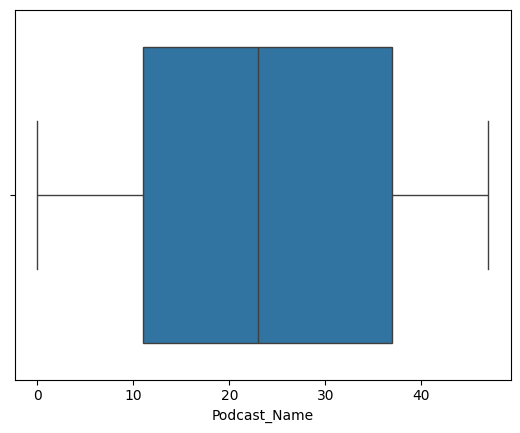

In [75]:
sns.boxplot(x = df_train['Podcast_Name'])

<Axes: xlabel='Episode_Title'>

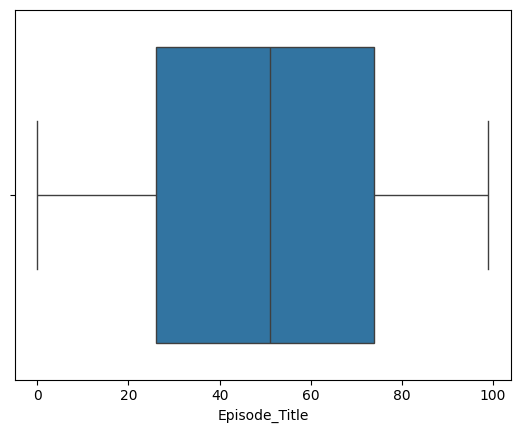

In [76]:
sns.boxplot(x = df_train['Episode_Title'])

<Axes: xlabel='Episode_Length_minutes'>

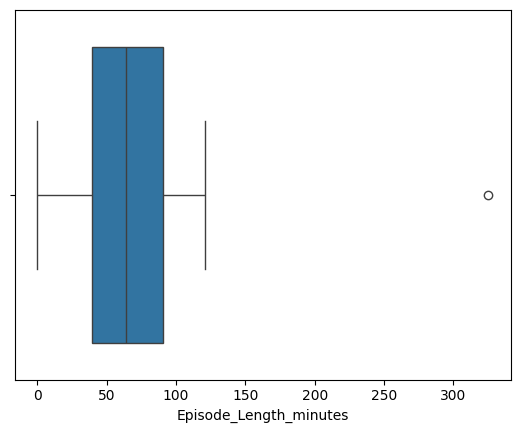

In [77]:
sns.boxplot(x = df_train['Episode_Length_minutes'])

<Axes: xlabel='Genre'>

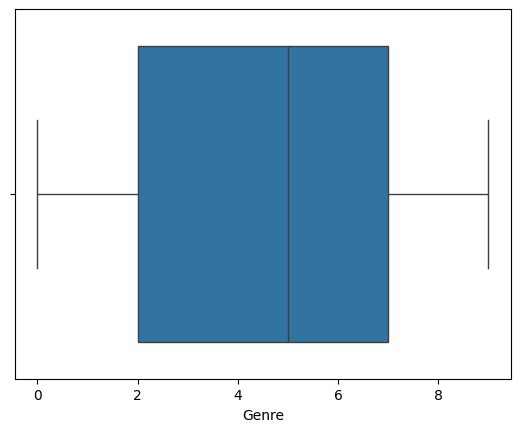

In [78]:
sns.boxplot(x = df_train['Genre'])

<Axes: xlabel='Host_Popularity_percentage'>

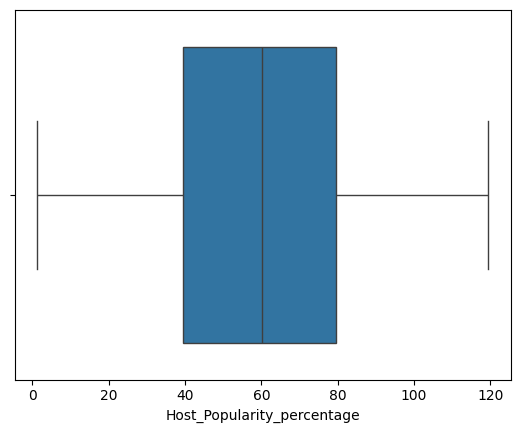

In [79]:
sns.boxplot(x = df_train['Host_Popularity_percentage'])

<Axes: xlabel='Publication_Day'>

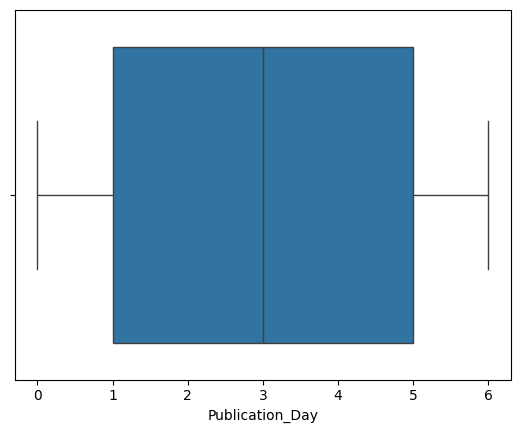

In [80]:
sns.boxplot(x = df_train['Publication_Day'])

<Axes: xlabel='Publication_Time'>

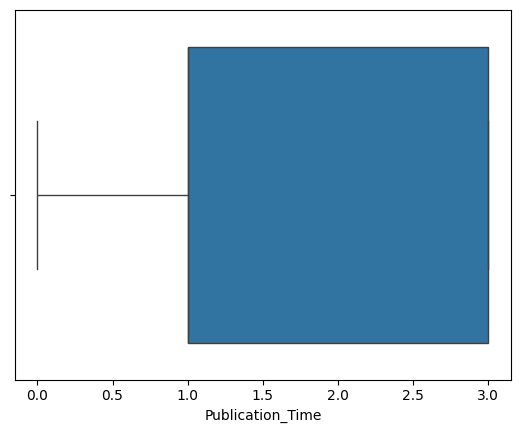

In [81]:
sns.boxplot(x = df_train['Publication_Time'])

<Axes: xlabel='Guest_Popularity_percentage'>

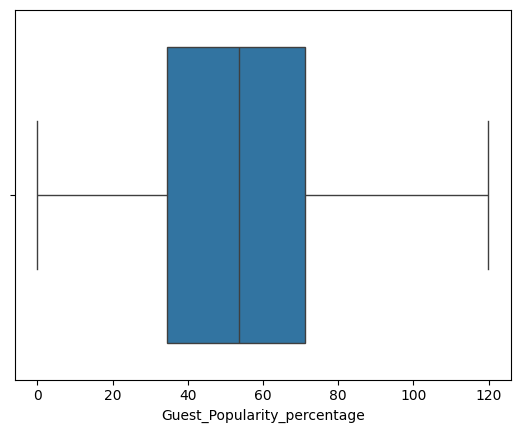

In [82]:
sns.boxplot(x = df_train['Guest_Popularity_percentage'])

<Axes: xlabel='Number_of_Ads'>

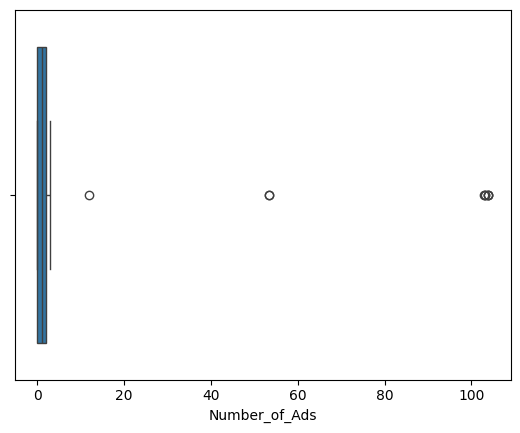

In [89]:
sns.boxplot(x = df_train['Number_of_Ads'])

<Axes: xlabel='Episode_Sentiment'>

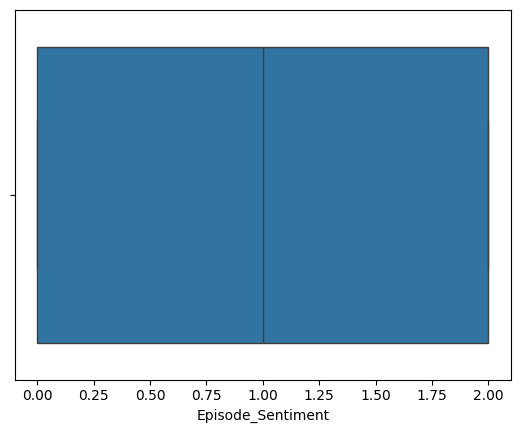

In [84]:
sns.boxplot(x = df_train['Episode_Sentiment'])

<Axes: xlabel='Listening_Time_minutes'>

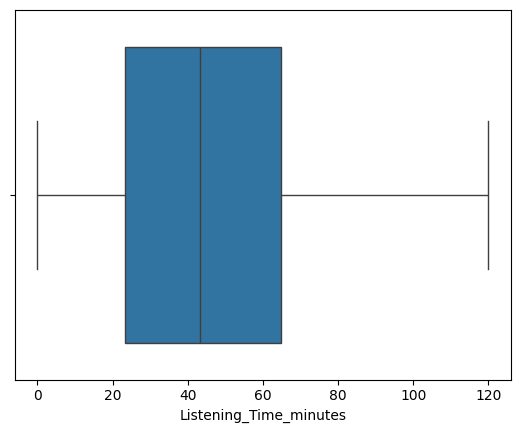

In [85]:
sns.boxplot(x = df_train['Listening_Time_minutes'])

In [90]:
X_train = df_train.drop('Listening_Time_minutes', axis=1)
y_train = df_train['Listening_Time_minutes']
X_test = df_test.copy()

In [91]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [92]:
poly = PolynomialFeatures()
model= LinearRegression()

In [93]:
pipe = Pipeline([('poly',poly),('model',model)])

In [94]:
params = {
    'poly__degree':[1, 2, 3, 4],
    'poly__include_bias':[False]
}

In [95]:
from sklearn.model_selection import GridSearchCV

In [96]:
final_model = GridSearchCV(pipe, params , cv = 3, verbose = 2)

In [97]:
final_model.fit(X_train,y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ...........poly__degree=1, poly__include_bias=False; total time=   0.1s
[CV] END ...........poly__degree=1, poly__include_bias=False; total time=   0.1s
[CV] END ...........poly__degree=1, poly__include_bias=False; total time=   0.1s
[CV] END ...........poly__degree=2, poly__include_bias=False; total time=   1.6s
[CV] END ...........poly__degree=2, poly__include_bias=False; total time=   1.5s
[CV] END ...........poly__degree=2, poly__include_bias=False; total time=   1.5s
[CV] END ...........poly__degree=3, poly__include_bias=False; total time=   7.6s
[CV] END ...........poly__degree=3, poly__include_bias=False; total time=   7.3s
[CV] END ...........poly__degree=3, poly__include_bias=False; total time=   7.3s
[CV] END ...........poly__degree=4, poly__include_bias=False; total time=  28.5s
[CV] END ...........poly__degree=4, poly__include_bias=False; total time=  27.9s
[CV] END ...........poly__degree=4, poly__include

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'poly__degree': [1, 2, ...], 'poly__include_bias': [False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [99]:
final_model.best_score_

np.float64(0.7609103452276617)

In [100]:
final_model.best_params_

{'poly__degree': 2, 'poly__include_bias': False}

In [101]:
y_pred = final_model.predict(X_test)

In [102]:
df_sub = pd.read_csv('sample_submission.csv')

In [103]:
df_sub['Listening_Time_minutes'] = y_pred

In [104]:
df_sub.to_csv('sub.csv',index = False,index_label= False)

In [105]:
df_sub

,id,Listening_Time_minutes
0,750000,54.868353
1,750001,18.128432
2,750002,51.277445
3,750003,81.142870
4,750004,48.257554
...,...,...
249995,999995,11.726687
249996,999996,57.864955
249997,999997,6.888465
249998,999998,76.518616
